# Graduate Project — FishEye8K + VisDrone → YOLOv11

| Cell | Nội dung |
|------|----------|
| 0 | Install |
| 1 | Config + hàm `to_fisheye()` + `transform_bbox_fisheye()` |
| 2 | Phase 1 — EDA + Split + Export YOLO labels (FishEye8K) |
| 3 | Phase 2 — Convert VisDrone (train+val+test-dev) → Fisheye + Merge |
| 4 | Phase 3 — Train YOLOv11l |
| 5 | Phase 4 — Validation + Per-class AP |
| 6 | Phase 5 — Save checkpoint + Export ONNX |

In [1]:
!pip install ultralytics==8.4.24 --no-deps -q
!pip install ultralytics-thop>=2.0.18 opencv-python==4.10.0.84 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch==2.3.1 torchvision==0.18.1 

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║ CELL 1 — CONFIG + FISHEYE FUNCTION + THỐNG KÊ LABELS        ║
# ║ Đã thêm: đếm số ảnh + số labels (bboxes) của FishEye8K      ║
# ║          và VisDrone để dễ đánh giá trước khi merge         ║
# ╚══════════════════════════════════════════════════════════════╝

import os, json, shutil, random, warnings, csv, io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import yaml
from tqdm import tqdm
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# ── GPU Info ─────────────────────────────────────────────────────
N_GPU = torch.cuda.device_count()
for i in range(N_GPU):
    vram = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {vram:.1f} GB')
print(f'NumPy: {np.__version__} | PyTorch: {torch.__version__}\n')

# ════════════════════════════════════════════════════════════════
# CONFIG — chỉnh tại đây
# ════════════════════════════════════════════════════════════════
YOLO_MODEL = 'yolo11l.pt'
EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 16
WORKERS = 2
SEED = 42
DEVICE = '0' if N_GPU >= 1 else 'cpu'
WANDB_KEY = ''                     # paste key hoặc để trống
FISHEYE_STRENGTH = 0.5             # 0.4 ~ 0.6 là tốt
VISDRONE_MAX = None                # None = dùng hết, hoặc đặt số (ví dụ: 5000)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────
FISHEYE_ROOT = Path('/kaggle/input/datasets/ducle19/fisheye8k')
TRAIN_IMG_DIR = FISHEYE_ROOT / 'train' / 'images'
TRAIN_ANN_FILE = FISHEYE_ROOT / 'train' / 'train.json'
TEST_IMG_DIR = FISHEYE_ROOT / 'test' / 'images'
TEST_ANN_FILE = FISHEYE_ROOT / 'test' / 'test.json'

VISDRONE_ROOT = Path('/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset')
VD_SPLITS = [
    ('train',     VISDRONE_ROOT / 'VisDrone2019-DET-train' / 'images',
                  VISDRONE_ROOT / 'VisDrone2019-DET-train' / 'labels'),
    ('val',       VISDRONE_ROOT / 'VisDrone2019-DET-val' / 'images',
                  VISDRONE_ROOT / 'VisDrone2019-DET-val' / 'labels'),
    ('test-dev',  VISDRONE_ROOT / 'VisDrone2019-DET-test-dev' / 'images',
                  VISDRONE_ROOT / 'VisDrone2019-DET-test-dev' / 'labels'),
]

# Output paths
WORKING = Path('/kaggle/working')
OUTPUT_ROOT = WORKING / 'fisheye8k_prepared'
YOLO_ROOT = OUTPUT_ROOT / 'yolo_dataset'
RUNS_DIR = WORKING / 'runs'
CKPT_DIR = WORKING / 'checkpoints'

for d in [OUTPUT_ROOT, YOLO_ROOT, RUNS_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Car', 'Bus', 'Truck', 'Pedestrian', 'Motorbike']
print(f"Classes: {len(CLASS_NAMES)} → {CLASS_NAMES}\n")

# ════════════════════════════════════════════════════════════════
# FISHEYE FUNCTION (giữ nguyên)
# ════════════════════════════════════════════════════════════════
def to_fisheye(img, strength=0.5, zoom=1.0):
    """Chuyển ảnh aerial thành fisheye barrel distortion"""
    src_h, src_w = img.shape[:2]
    cx, cy = src_w / 2.0, src_h / 2.0
    R = min(src_w, src_h) / 2.0
    ys, xs = np.mgrid[0:src_h, 0:src_w].astype(np.float64)
    dx = (xs - cx) / R
    dy = (ys - cy) / R
    r_dst = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    s = max(min(float(strength), 1.0), 1e-6)
    r_src = np.where(
        r_dst > 1e-9,
        np.tan(r_dst * s * np.pi / 2.0) / np.tan(s * np.pi / 2.0),
        r_dst,
    )
    r_src = np.clip(r_src, 0, None) / zoom
    src_x = np.clip(r_src * np.cos(theta) * R + cx, 0, src_w - 1).astype(np.float32)
    src_y = np.clip(r_src * np.sin(theta) * R + cy, 0, src_h - 1).astype(np.float32)
    return cv2.remap(img, src_x, src_y, cv2.INTER_LANCZOS4,
                     borderMode=cv2.BORDER_CONSTANT, borderValue=0)

# ── Thống kê FishEye8K (ảnh + labels) ─────────────────────────────
def count_fisheye_labels(ann_file):
    if not ann_file.exists():
        return 0
    with open(ann_file) as f:
        data = json.load(f)
    return len(data.get('annotations', []))

print("=== THỐNG KÊ FISH EYE 8K ===")
n_train_img = len(list(TRAIN_IMG_DIR.glob("*")))
n_train_lbl = count_fisheye_labels(TRAIN_ANN_FILE)
n_test_img  = len(list(TEST_IMG_DIR.glob("*")))
print(f"FishEye8K Train : {n_train_img:,} ảnh  |  {n_train_lbl:,} labels")
print(f"FishEye8K Test  : {n_test_img:,} ảnh\n")

# ── Thống kê VisDrone (ảnh + labels) ──────────────────────────────
print("=== THỐNG KÊ VISDRONE ===")
total_vd_img = 0
total_vd_lbl = 0
for split_name, img_dir, ann_dir in VD_SPLITS:
    n_img = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
    n_lbl = 0
    if ann_dir.exists():
        n_lbl = sum(1 for f in ann_dir.glob("*.txt") for line in open(f) if line.strip())
    total_vd_img += n_img
    total_vd_lbl += n_lbl
    status = '✓' if img_dir.exists() and ann_dir.exists() else '✗ NOT FOUND'
    print(f"VisDrone {split_name:9s}: {n_img:,} ảnh  |  {n_lbl:,} labels  {status}")

print(f"\nTổng VisDrone     : {total_vd_img:,} ảnh  |  {total_vd_lbl:,} labels\n")

# ── Kiểm tra paths quan trọng ─────────────────────────────────────
assert TRAIN_ANN_FILE.exists(), f"Không tìm thấy: {TRAIN_ANN_FILE}"
assert TRAIN_IMG_DIR.exists(), f"Không tìm thấy: {TRAIN_IMG_DIR}"

print(f"Device          : {DEVICE}")
print(f"FISHEYE_STRENGTH: {FISHEYE_STRENGTH}")
if VISDRONE_MAX:
    print(f"VISDRONE_MAX    : {VISDRONE_MAX:,} (giới hạn)")

# ── Colors ───────────────────────────────────────────────────────
COLORS = ['#1D9E75', '#7F77DD', '#378ADD', '#D85A30', '#BA7517']

# ── Transform bbox theo fisheye distortion ────────────────────────
def transform_bbox_fisheye(bbox_xywh, src_w, src_h, strength=0.5, zoom=1.0, n_pts=8):
    bx, by, bw, bh = bbox_xywh
    if bw <= 0 or bh <= 0:
        return None

    top    = [(bx + bw * t, by          ) for t in np.linspace(0, 1, n_pts)]
    bottom = [(bx + bw * t, by + bh     ) for t in np.linspace(0, 1, n_pts)]
    left   = [(bx,          by + bh * t ) for t in np.linspace(0, 1, n_pts)]
    right  = [(bx + bw,     by + bh * t ) for t in np.linspace(0, 1, n_pts)]
    pts = np.array(top + bottom + left + right, dtype=np.float64)

    cx, cy = src_w / 2.0, src_h / 2.0
    R = min(src_w, src_h) / 2.0
    s = max(min(float(strength), 1.0), 1e-6)
    factor = np.tan(s * np.pi / 2.0)

    dx = (pts[:, 0] - cx) / R
    dy = (pts[:, 1] - cy) / R
    r  = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)

    r_dst = np.where(
        r > 1e-9,
        (2.0 * np.arctan(r * factor)) / (s * np.pi),
        r,
    ) * zoom

    new_x = r_dst * np.cos(theta) * R + cx
    new_y = r_dst * np.sin(theta) * R + cy

    nx1, ny1 = new_x.min(), new_y.min()
    nx2, ny2 = new_x.max(), new_y.max()
    nx1 = max(0, nx1); ny1 = max(0, ny1)
    nx2 = min(src_w - 1, nx2); ny2 = min(src_h - 1, ny2)
    nw  = nx2 - nx1; nh  = ny2 - ny1
    if nw < 1 or nh < 1:
        return None
    return [nx1, ny1, nw, nh]
print("\n✅ CELL 1 HOÀN THÀNH — CONFIG + FISHEYE + THỐNG KÊ LABELS OK")
print("→ Chạy tiếp Cell 2\n")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU 0: Tesla P100-PCIE-16GB — 17.1 GB
NumPy: 2.0.2 | PyTorch: 2.3.1+cu121

Classes: 5 → ['Car', 'Bus', 'Truck', 'Pedestrian', 'Motorbike']

=== THỐNG KÊ FISH EYE 8K ===
FishEye8K Train : 5,288 ảnh  |  112,213 labels
FishEye8K Test  : 2,712 ảnh

=== THỐNG KÊ VISDRONE ===
VisDrone train    : 6,471 ảnh  |  343,205 labels  ✓
VisDrone val      : 548 ảnh  |  38,759 labels  ✓
VisDrone test-dev : 1,610 ảnh  |  75,102 labels  ✓

Tổng VisDrone     : 8,629 ảnh  |  457,066 labels

Device          : 0
FISHEYE_STRENGTH: 0.5

✅ CELL 1 HOÀN THÀNH — CONFIG + FISHEYE + THỐNG KÊ LABELS OK
→ Chạy tiếp Cell 2



Train images      : 5,288
Train annotations : 112,213
Test  images      : 2,712
Categories        : ['Bus', 'Bike', 'Car', 'Pedestrian', 'Truck']

DataFrame: 112,213 rows | 5,288 images | 15 cameras


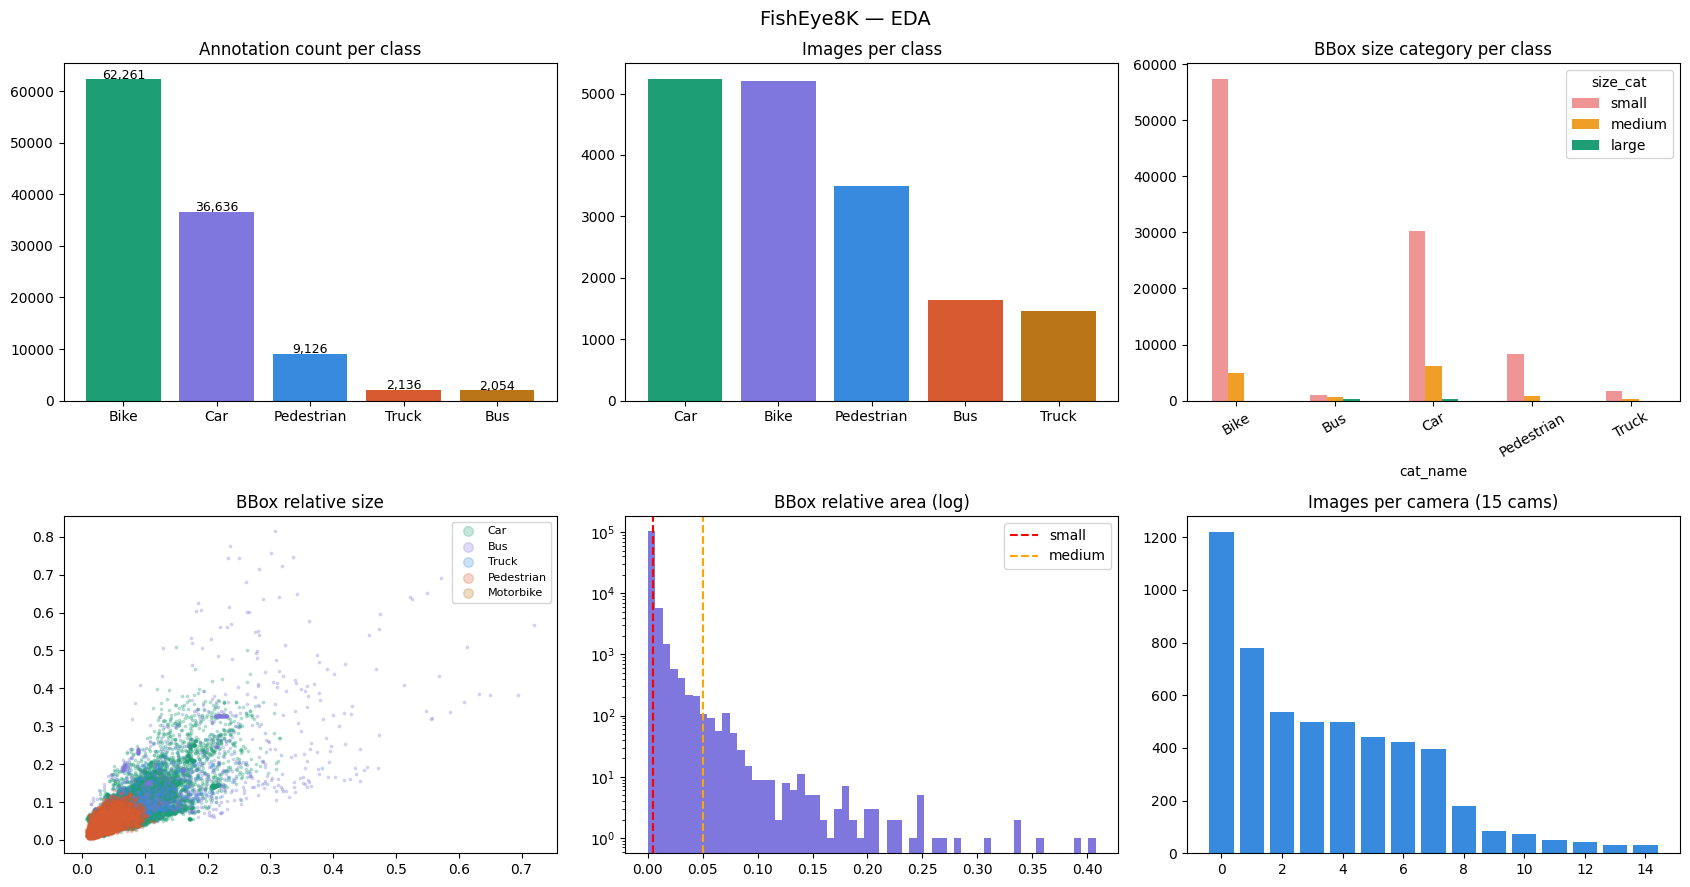

Imbalance: 30.3x | Small: 87.9%

Split summary (70/20/10):
       cameras  images  annotations
split                              
test         2     853        19610
train       10    2667        60773
val          3    1768        31830


Export train: 100%|██████████| 2667/2667 [00:11<00:00, 242.27it/s]


  [train] 2,667 images exported


Export val: 100%|██████████| 1768/1768 [00:06<00:00, 262.86it/s]


  [val] 1,768 images exported


Export test: 100%|██████████| 853/853 [00:03<00:00, 222.20it/s]


  [test] 853 images exported


Link unlabelled test: 100%|██████████| 2712/2712 [00:07<00:00, 357.55it/s]


dataset.yaml → /kaggle/working/fisheye8k_prepared/yolo_dataset/dataset.yaml
PHASE 1 DONE — chạy Cell 3 (VisDrone convert)


In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — PHASE 1: FishEye8K EDA + SPLIT + EXPORT YOLO      ║
# ╚══════════════════════════════════════════════════════════════╝
COLORS = ['#1D9E75', '#7F77DD', '#378ADD', '#D85A30', '#BA7517']
# ── 1. Load COCO JSON ─────────────────────────────────────────────
with open(TRAIN_ANN_FILE) as f: coco = json.load(f)
with open(TEST_ANN_FILE)  as f: coco_test = json.load(f)

cat_id2name = {c['id']: c['name'] for c in coco['categories']}
img_id2info = {img['id']: img     for img in coco['images']}

print(f'Train images      : {len(coco["images"]):,}')
print(f'Train annotations : {len(coco["annotations"]):,}')
print(f'Test  images      : {len(coco_test["images"]):,}')
print(f'Categories        : {[c["name"] for c in coco["categories"]]}')

# ── 2. Build DataFrame ────────────────────────────────────────────
buf = io.StringIO()
writer = csv.writer(buf)
writer.writerow(['ann_id','image_id','cat_name','file_name',
                 'img_w','img_h','bbox_x','bbox_y','bbox_w','bbox_h','camera_id'])
for ann in coco['annotations']:
    img   = img_id2info[ann['image_id']]
    fname = img['file_name']
    cam   = '_'.join(Path(fname).stem.split('_')[:2])
    x,y,w,h = ann['bbox']
    writer.writerow([ann['id'], ann['image_id'],
                     cat_id2name[ann['category_id']], fname,
                     img['width'], img['height'], x, y, w, h, cam])
buf.seek(0)
df = pd.read_csv(buf)
df['rel_w']    = df['bbox_w'] / df['img_w']
df['rel_h']    = df['bbox_h'] / df['img_h']
df['rel_area'] = df['rel_w'] * df['rel_h']
df['size_cat'] = pd.cut(df['rel_area'], bins=[0,0.005,0.05,1.0],
                        labels=['small','medium','large'])
print(f'\nDataFrame: {len(df):,} rows | {df["image_id"].nunique():,} images | {df["camera_id"].nunique()} cameras')

# ── 3. EDA plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
cc = df['cat_name'].value_counts()
axes[0,0].bar(cc.index, cc.values, color=COLORS[:len(cc)])
axes[0,0].set_title('Annotation count per class')
for i,v in enumerate(cc.values): axes[0,0].text(i, v+50, f'{v:,}', ha='center', fontsize=9)

ipc = df.groupby('cat_name')['image_id'].nunique().sort_values(ascending=False)
axes[0,1].bar(ipc.index, ipc.values, color=COLORS[:len(ipc)])
axes[0,1].set_title('Images per class')

size_tbl = df.groupby(['cat_name','size_cat'], observed=False).size().unstack(fill_value=0)
size_tbl.plot(kind='bar', ax=axes[0,2], color=['#F09595','#EF9F27','#1D9E75'])
axes[0,2].set_title('BBox size category per class')
axes[0,2].tick_params(axis='x', rotation=30)

for i, cls in enumerate(CLASS_NAMES):
    sub = df[df['cat_name']==cls]
    axes[1,0].scatter(sub['rel_w'], sub['rel_h'], s=3, alpha=0.25, label=cls, color=COLORS[i])
axes[1,0].set_title('BBox relative size'); axes[1,0].legend(markerscale=4, fontsize=8)

axes[1,1].hist(df['rel_area'].astype(float), bins=60, color='#7F77DD', log=True)
axes[1,1].axvline(0.005, color='red',    ls='--', label='small')
axes[1,1].axvline(0.05,  color='orange', ls='--', label='medium')
axes[1,1].set_title('BBox relative area (log)'); axes[1,1].legend()

cam_imgs = df.groupby('camera_id')['image_id'].nunique().sort_values(ascending=False)
axes[1,2].bar(range(len(cam_imgs)), cam_imgs.values, color='#378ADD')
axes[1,2].set_title(f'Images per camera ({len(cam_imgs)} cams)')
plt.suptitle('FishEye8K — EDA', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT/'eda_summary.png', dpi=150); plt.show()
print(f'Imbalance: {cc.max()/cc.min():.1f}x | Small: {(df["size_cat"]=="small").mean()*100:.1f}%')

# ── 4. Split theo camera (70/20/10) ─────────────────────────────
cameras = list(cam_imgs.index); random.shuffle(cameras)
n_train = int(len(cameras) * 0.70)
n_val   = int(len(cameras) * 0.20)
train_cams = set(cameras[:n_train])
val_cams   = set(cameras[n_train:n_train + n_val])
test_cams  = set(cameras[n_train + n_val:])

def assign_split(cam):
    if cam in train_cams: return 'train'
    if cam in val_cams:   return 'val'
    return 'test'

df['split'] = df['camera_id'].apply(assign_split)
print('\nSplit summary (70/20/10):')
print(df.groupby('split').agg(
    cameras=('camera_id','nunique'), images=('image_id','nunique'), annotations=('ann_id','count')
))

# ── 5. Export YOLO labels ─────────────────────────────────────────
def export_yolo(df_split, split_name, img_src):
    img_out = YOLO_ROOT / split_name / 'images'
    lbl_out = YOLO_ROOT / split_name / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    n = 0
    for fname, grp in tqdm(df_split.groupby('file_name'), desc=f'Export {split_name}'):
        src = img_src / fname; dst = img_out / fname
        if src.exists() and not dst.exists():
            try:    os.symlink(src.resolve(), dst)
            except: shutil.copy2(src, dst)
        iw = float(grp['img_w'].iloc[0]); ih = float(grp['img_h'].iloc[0])
        seen = set()
        with open(lbl_out / f'{Path(fname).stem}.txt', 'w') as lf:
            for _, r in grp.iterrows():
                cls = CLASS_NAMES.index(r['cat_name']) if r['cat_name'] in CLASS_NAMES else 0
                cx  = (r['bbox_x'] + r['bbox_w']/2) / iw
                cy  = (r['bbox_y'] + r['bbox_h']/2) / ih
                nw  = r['bbox_w'] / iw
                nh  = r['bbox_h'] / ih
                key = (round(cx,4), round(cy,4), round(nw,4), round(nh,4))
                if key not in seen:
                    seen.add(key)
                    lf.write(f'{cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n')
        n += 1
    print(f'  [{split_name}] {n:,} images exported')

export_yolo(df[df['split']=='train'], 'train', TRAIN_IMG_DIR)
export_yolo(df[df['split']=='val'],   'val',   TRAIN_IMG_DIR)
export_yolo(df[df['split']=='test'],  'test',  TRAIN_IMG_DIR)

# Unlabelled test set (coco_test) — symlink ảnh vào thư mục riêng
unlabelled_out = YOLO_ROOT / 'test_unlabelled' / 'images'
unlabelled_out.mkdir(parents=True, exist_ok=True)
for img_info in tqdm(coco_test['images'], desc='Link unlabelled test'):
    src_path = TEST_IMG_DIR / img_info['file_name']
    dst_path  = unlabelled_out / img_info['file_name']
    if src_path.exists() and not dst_path.exists():
        try:    os.symlink(src_path.resolve(), dst_path)
        except: shutil.copy2(src_path, dst_path)

# dataset.yaml
DATASET_YAML = YOLO_ROOT / 'dataset.yaml'
with open(DATASET_YAML, 'w') as f:
    yaml.dump({'path': str(YOLO_ROOT), 'train': 'train/images',
               'val': 'val/images', 'test': 'test/images',
               'nc': len(CLASS_NAMES), 'names': CLASS_NAMES}, f)
# Ghi chú: test_unlabelled/ chứa ảnh từ coco_test (không có nhãn, dùng cho inference)
print(f'\ndataset.yaml → {DATASET_YAML}')
print('PHASE 1 DONE — chạy Cell 3 (VisDrone convert)')

In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║ CELL 3 — TEST 100 ẢNH (DÙNG ĐỊNH DẠNG YOLO MỚI)              ║
# ║ Copy labels đã ở dạng YOLO, chỉ đổi tên file                 ║
# ║ Ảnh fisheye sẽ xử lý ở cell sau                              ║
# ╚══════════════════════════════════════════════════════════════╝

print("=== CELL 3: TEST 100 ảnh - DÙNG ĐỊNH DẠNG YOLO MỚI ===\n")

# Thư mục nguồn labels (định dạng YOLO mới)
# Nếu thư mục annotation của bạn khác, hãy sửa dòng dưới
SOURCE_LABEL_DIR = VISDRONE_ROOT / 'VisDrone2019-DET-train' / 'labels'   # ← sửa nếu cần

SYNTH_LBL = YOLO_ROOT / "train" / "labels"
SYNTH_LBL.mkdir(parents=True, exist_ok=True)

# Lấy 100 ảnh đầu tiên để test
all_tasks = []
for split_name, img_dir, ann_dir in VD_SPLITS:
    if img_dir.exists():
        files = sorted(img_dir.glob("*.jpg")) + sorted(img_dir.glob("*.png"))
        all_tasks += [(p, ann_dir, split_name) for p in files]

test_tasks = all_tasks[:100]

print(f"Đang copy labels cho {len(test_tasks)} ảnh đầu tiên...\n")

copied = 0
total_labels = 0

for img_path, ann_dir, split_name in tqdm(test_tasks, desc="Copy Labels YOLO mới"):

    # Tìm file label gốc (định dạng YOLO)
    source_lbl_path = ann_dir / (img_path.stem + ".txt")
    
    yolo_lines = []
    
    if source_lbl_path.exists():
        with open(source_lbl_path, encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    yolo_lines.append(line)
                    total_labels += 1   # đếm số dòng (số bbox)
    
    # Tạo tên file mới
    out_name = f"test_vd_{split_name}_{img_path.stem}"
    
    # Lưu label (dùng định dạng mới luôn)
    with open(SYNTH_LBL / f"{out_name}.txt", "w", encoding='utf-8') as lf:
        if yolo_lines:
            lf.write("\n".join(yolo_lines))
    
    copied += 1


# ── Kết quả ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("=== KẾT QUẢ COPY LABELS (ĐỊNH DẠNG YOLO MỚI) ===")
print("="*65)
print(f"Đã copy labels          : {copied} files")
print(f"Total labels (bboxes)   : {total_labels:,}")
print(f"Thư mục lưu             : {SYNTH_LBL}")

if total_labels > 0:
    print("\n✅ THÀNH CÔNG! Đã copy labels theo định dạng YOLO mới.")
    print("   → Bây giờ bạn có thể tạo Cell 4 để xử lý ảnh fisheye và ghép tên file.")
else:
    print("\n❌ Không có labels nào được copy.")
    print("   Hãy kiểm tra lại đường dẫn SOURCE_LABEL_DIR hoặc VD_SPLITS.")

print("\nGợi ý tiếp theo: Tạo Cell 4 để convert ảnh sang fisheye và đồng bộ tên file với labels.")

=== CELL 3: TEST 100 ảnh - DÙNG ĐỊNH DẠNG YOLO MỚI ===

Đang copy labels cho 100 ảnh đầu tiên...



Copy Labels YOLO mới: 100%|██████████| 100/100 [00:00<00:00, 652.95it/s]


=== KẾT QUẢ COPY LABELS (ĐỊNH DẠNG YOLO MỚI) ===
Đã copy labels          : 100 files
Total labels (bboxes)   : 9,140
Thư mục lưu             : /kaggle/working/fisheye8k_prepared/yolo_dataset/train/labels

✅ THÀNH CÔNG! Đã copy labels theo định dạng YOLO mới.
   → Bây giờ bạn có thể tạo Cell 4 để xử lý ảnh fisheye và ghép tên file.

Gợi ý tiếp theo: Tạo Cell 4 để convert ảnh sang fisheye và đồng bộ tên file với labels.


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — PHASE 2: VISDRONE → FISHEYE + MERGE               ║
# ║  Labels VisDrone đã ở định dạng YOLO → đọc trực tiếp        ║
# ╚══════════════════════════════════════════════════════════════╝

# Class mapping VisDrone YOLO index → FishEye8K index
# VisDrone: 0=ignored,1=pedestrian,2=people,3=bicycle,4=car,
#           5=van,6=truck,7=tricycle,8=awning-tricycle,9=bus,10=motor
VD_CAT_MAP = {
    1: 3, 2: 3,   # pedestrian/people → Pedestrian
    3: 4, 7: 4, 8: 4, 10: 4,  # bicycle/tricycle/motor → Motorbike
    4: 0, 5: 0,   # car/van → Car
    6: 2,         # truck → Truck
    9: 1,         # bus → Bus
}

SYNTH_IMG = YOLO_ROOT / "train" / "images"
SYNTH_LBL = YOLO_ROOT / "train" / "labels"
SYNTH_IMG.mkdir(parents=True, exist_ok=True)
SYNTH_LBL.mkdir(parents=True, exist_ok=True)

# Gom tasks
all_tasks = []
for split_name, img_dir, ann_dir in VD_SPLITS:
    if img_dir.exists() and ann_dir.exists():
        files = sorted(img_dir.glob("*.jpg")) + sorted(img_dir.glob("*.png"))
        all_tasks += [(p, ann_dir, split_name) for p in files]
        print(f"  VisDrone {split_name:9s}: {len(files):,} images")
    else:
        print(f"  VisDrone {split_name:9s}: SKIP — path not found")

if VISDRONE_MAX:
    all_tasks = all_tasks[:VISDRONE_MAX]
print(f"\nTổng sẽ convert: {len(all_tasks):,} images\n")

# Convert loop
converted    = 0
skip_no_img  = 0
skip_no_ann  = 0
total_labels = 0

for img_path, ann_dir, split_name in tqdm(all_tasks, desc="VisDrone → Fisheye"):

    # Đọc ảnh
    img = cv2.imread(str(img_path.resolve()))
    if img is None:
        skip_no_img += 1
        continue
    src_h, src_w = img.shape[:2]

    # Convert sang fisheye
    fisheye = to_fisheye(img, strength=FISHEYE_STRENGTH)

    # Đọc label YOLO gốc và remap class + transform bbox
    yolo_lines = []
    ann_path = ann_dir / (img_path.stem + ".txt")

    if ann_path.exists():
        with open(ann_path) as af:
            for line in af:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                try:
                    cls_orig = int(parts[0])
                    cx, cy, nw, nh = float(parts[1]), float(parts[2]), \
                                     float(parts[3]), float(parts[4])
                except ValueError:
                    continue

                # Remap class
                cls_new = VD_CAT_MAP.get(cls_orig)
                if cls_new is None:
                    continue  # class ignored (0) hoặc không map được

                # Chuyển YOLO normalized → pixel để transform fisheye
                bx = int((cx - nw / 2) * src_w)
                by = int((cy - nh / 2) * src_h)
                bw = int(nw * src_w)
                bh = int(nh * src_h)

                nb = transform_bbox_fisheye(
                    [bx, by, bw, bh], src_w, src_h,
                    strength=FISHEYE_STRENGTH
                )
                if nb is None:
                    continue

                nx, ny, nw2, nh2 = nb
                cx_n = (nx + nw2 / 2) / src_w
                cy_n = (ny + nh2 / 2) / src_h
                rnw  = nw2 / src_w
                rnh  = nh2 / src_h

                if rnw < 0.004 or rnh < 0.004:
                    continue

                yolo_lines.append(f"{cls_new} {cx_n:.6f} {cy_n:.6f} {rnw:.6f} {rnh:.6f}")
                total_labels += 1
    else:
        skip_no_ann += 1

    # Lưu ảnh + label (dù rỗng cũng lưu để YOLO không báo thiếu file)
    out_name = f"vd_{split_name}_{img_path.stem}"
    cv2.imwrite(str(SYNTH_IMG / f"{out_name}.jpg"), fisheye,
                [cv2.IMWRITE_JPEG_QUALITY, 92])
    with open(SYNTH_LBL / f"{out_name}.txt", "w") as lf:
        lf.write("\n".join(yolo_lines))
    converted += 1

# Thống kê
n_train = len(list((YOLO_ROOT / "train" / "images").glob("*")))
n_val   = len(list((YOLO_ROOT / "val"   / "images").glob("*")))
n_test  = len(list((YOLO_ROOT / "test"  / "images").glob("*")))
n_ann   = sum(len(open(f).readlines()) for f in (YOLO_ROOT/"train"/"labels").glob("*.txt"))

print(f"\nConverted  : {converted:,}")
print(f"Skip no img: {skip_no_img:,}")
print(f"Skip no ann: {skip_no_ann:,}")
print(f"Total bbox : {total_labels:,}")
print(f"\n=== Dataset sau merge ===")
print(f"Train : {n_train:,}  |  Val : {n_val:,}  |  Test : {n_test:,}")
print(f"Train ann : {n_ann:,}")
print("PHASE 2 DONE — chạy Cell 4 (Train)")

  VisDrone train    : 6,471 images
  VisDrone val      : 548 images
  VisDrone test-dev : 1,610 images

Tổng sẽ convert: 8,629 images



VisDrone → Fisheye: 100%|██████████| 8629/8629 [47:43<00:00,  3.01it/s]



Converted  : 8,629
Skip no img: 0
Skip no ann: 0
Total bbox : 336,449

=== Dataset sau merge ===
Train : 11,296  |  Val : 1,768  |  Test : 853
Train ann : 406,355
PHASE 2 DONE — chạy Cell 4 (Train)


Fresh start: yolo11l.pt
Params: 25.4M
Batch: 16 | imgsz: 640 | Epochs: 50

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.3.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fisheye8k_prepared/yolo_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.005, mask_ratio=4, m

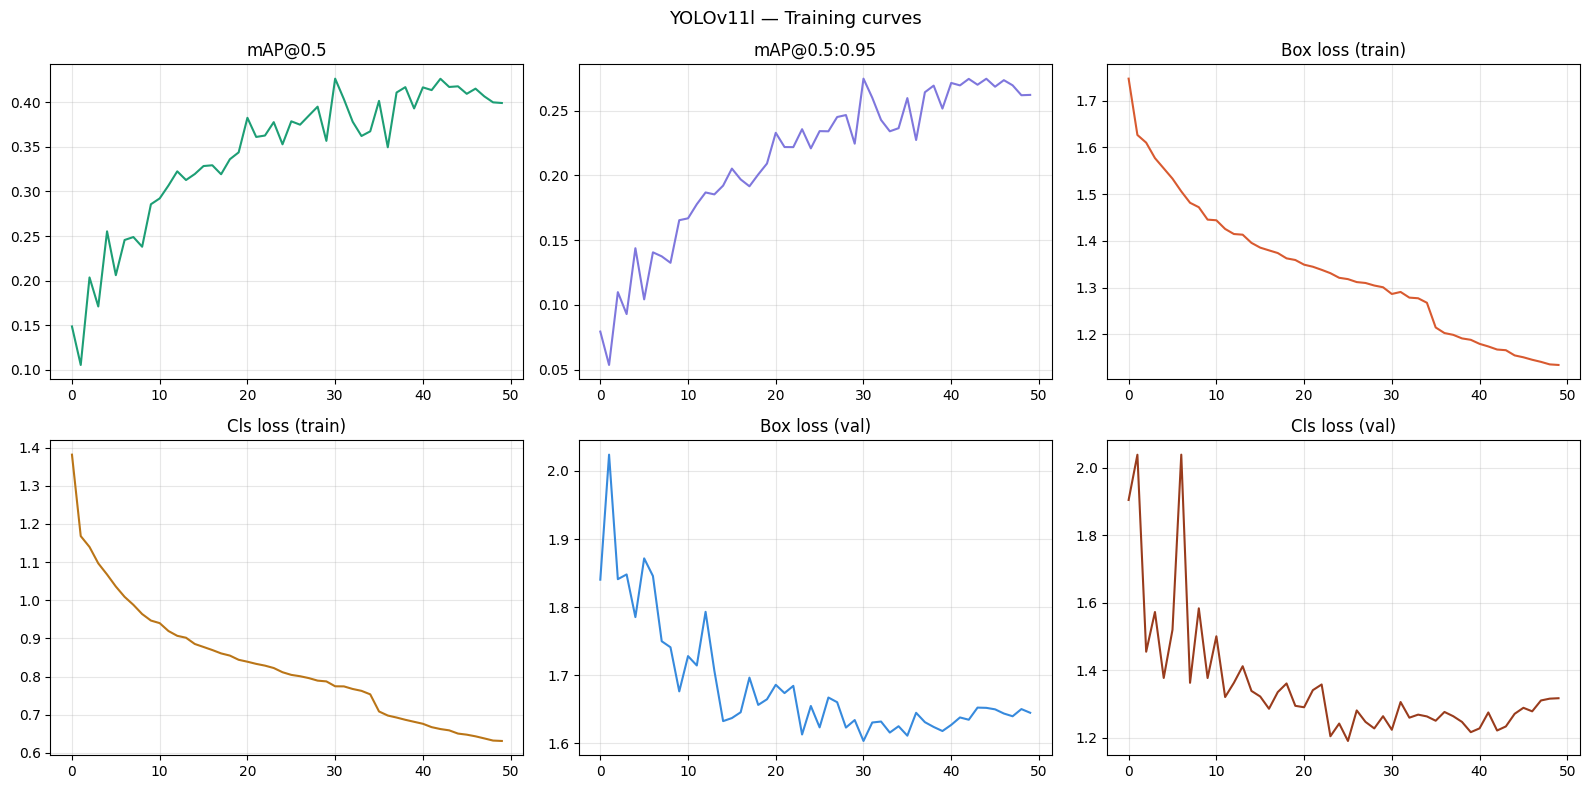

Best mAP@0.5: 0.4266
PHASE 3 DONE — chạy Cell 5 (Validation)


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — PHASE 3: TRAIN YOLOv11l                           ║
# ╚══════════════════════════════════════════════════════════════╝

DATASET_YAML = YOLO_ROOT / 'dataset.yaml'
RUN_NAME     = 'yolo11_fisheye'
assert DATASET_YAML.exists(), 'Chạy Cell 2 trước'

# Auto-resume
last_ckpt = RUNS_DIR / RUN_NAME / 'weights' / 'last.pt'
if last_ckpt.exists():
    print(f'Checkpoint found → RESUME: {last_ckpt}')
    model = YOLO(str(last_ckpt)); RESUME = True
else:
    print(f'Fresh start: {YOLO_MODEL}')
    model = YOLO(YOLO_MODEL); RESUME = False

print(f'Params: {sum(p.numel() for p in model.model.parameters())/1e6:.1f}M')
print(f'Batch: {BATCH_SIZE} | imgsz: {IMG_SIZE} | Epochs: {EPOCHS}\n')

results = model.train(
    data    = str(DATASET_YAML),
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    workers = WORKERS,
    device  = DEVICE,
    resume  = RESUME,

    # Optimizer
    optimizer    = 'AdamW',
    lr0          = 0.0005,
    lrf          = 0.005,
    weight_decay = 0.0005,
    warmup_epochs= 5,

    # Augmentation
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    flipud=0.1,  fliplr=0.5,
    mosaic=1.0,  mixup=0.05,  copy_paste=0.05,
    degrees=5.0, translate=0.1, scale=0.5,
    shear=1.0,   perspective=0.0001,
    erasing=0.3,
    close_mosaic=15,

    # Save
    project     = str(RUNS_DIR),
    name        = RUN_NAME,
    save        = True,
    save_period = 10,
    exist_ok    = True,

    # Performance
    amp      = True,
    cache    = 'disk',
    patience = 30,
    plots    = True,
    verbose  = True,
)

# Training curves
csv_path = RUNS_DIR / RUN_NAME / 'results.csv'
if csv_path.exists():
    df_res = pd.read_csv(csv_path); df_res.columns = df_res.columns.str.strip()
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    pairs = [
        ('metrics/mAP50(B)',    'mAP@0.5',         '#1D9E75'),
        ('metrics/mAP50-95(B)', 'mAP@0.5:0.95',    '#7F77DD'),
        ('train/box_loss',      'Box loss (train)', '#D85A30'),
        ('train/cls_loss',      'Cls loss (train)', '#BA7517'),
        ('val/box_loss',        'Box loss (val)',   '#378ADD'),
        ('val/cls_loss',        'Cls loss (val)',   '#993C1D'),
    ]
    for (col, title, color), ax in zip(pairs, axes.flat):
        if col in df_res.columns:
            ax.plot(df_res[col], color=color); ax.set_title(title); ax.grid(alpha=0.3)
    plt.suptitle('YOLOv11l — Training curves', fontsize=13)
    plt.tight_layout()
    plt.savefig(RUNS_DIR/RUN_NAME/'training_curves.png', dpi=150); plt.show()
    print(f'Best mAP@0.5: {df_res["metrics/mAP50(B)"].max():.4f}')

print('PHASE 3 DONE — chạy Cell 5 (Validation)')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.3.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11l summary (fused): 191 layers, 25,283,167 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 51.6±24.1 MB/s, size: 1689.4 KB)
val: Scanning /kaggle/working/fisheye8k_prepared/yolo_dataset/val/labels.cache... 1768 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1768/1768 529.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.9it/s 38.8s
                   all       1768      31830      0.676      0.351      0.427      0.275
                   Car       1768      28703      0.695      0.363      0.516      0.295
                   Bus        259        283      0.535      0.456       0.45      0.341
                 Truck        123        129      0.613      0.512      0.472      0.336
            Pedestrian       1240       2715       0.86     0.0747      0.272      0.12

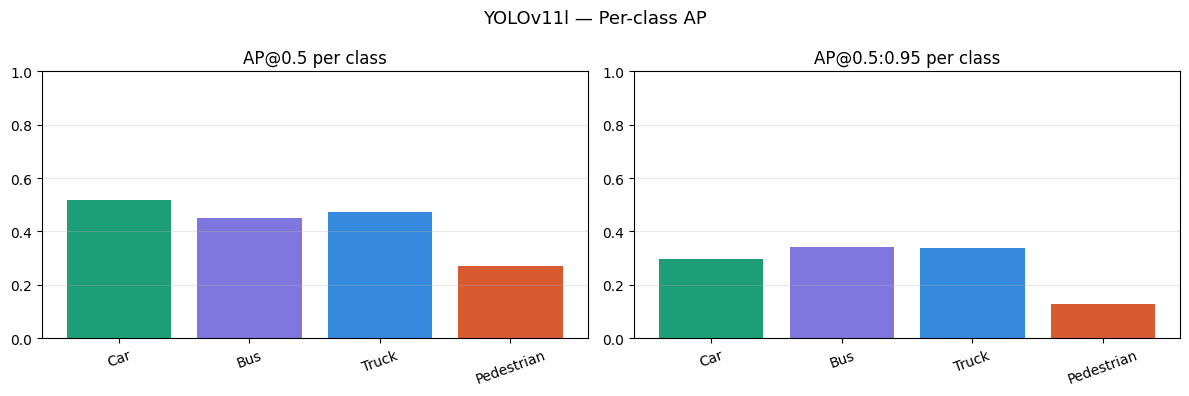

PHASE 4 DONE — chạy Cell 6 (Save + Export)


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — PHASE 4: VALIDATION + PER-CLASS AP                ║
# ╚══════════════════════════════════════════════════════════════╝

DATASET_YAML = YOLO_ROOT / 'dataset.yaml'
RUN_NAME     = 'yolo11_fisheye'

best_ckpt  = RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'
best_model = YOLO(str(best_ckpt))

val_results = best_model.val(
    data      = str(DATASET_YAML),
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    device    = DEVICE,
    split     = 'val',
    verbose   = True,
    plots     = True,
    save_json = True,
)

print('\n=== Per-class AP ===')
rows_val = []
for i, name in enumerate(CLASS_NAMES):
    try:
        ap50   = float(val_results.box.ap50[i])
        ap5095 = float(val_results.box.ap[i])
        print(f'  {name:12s}  AP50={ap50:.3f}  AP50:95={ap5095:.3f}')
        rows_val.append({'class': name, 'AP50': ap50, 'AP50:95': ap5095})
    except Exception:
        pass

print(f'\nmAP@0.5      : {val_results.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {val_results.box.map:.4f}')

df_val = pd.DataFrame(rows_val)
if not df_val.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(df_val['class'], df_val['AP50'],    color=COLORS); axes[0].set_ylim(0,1)
    axes[0].set_title('AP@0.5 per class'); axes[0].tick_params(axis='x', rotation=20)
    axes[1].bar(df_val['class'], df_val['AP50:95'], color=COLORS); axes[1].set_ylim(0,1)
    axes[1].set_title('AP@0.5:0.95 per class'); axes[1].tick_params(axis='x', rotation=20)
    for ax in axes: ax.grid(axis='y', alpha=0.3)
    plt.suptitle('YOLOv11l — Per-class AP', fontsize=13)
    plt.tight_layout()
    plt.savefig(RUNS_DIR/RUN_NAME/'perclass_ap.png', dpi=150); plt.show()

df_val.to_csv(WORKING / 'perclass_ap.csv', index=False)
print('PHASE 4 DONE — chạy Cell 6 (Save + Export)')

In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — PHASE 5: SAVE CHECKPOINT + EXPORT ONNX            ║
# ╚══════════════════════════════════════════════════════════════╝

RUN_NAME = 'yolo11_fisheye'

best_src = RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'
last_src = RUNS_DIR / RUN_NAME / 'weights' / 'last.pt'
best_dst = CKPT_DIR / 'yolo11_fisheye_best.pt'
last_dst = CKPT_DIR / 'yolo11_fisheye_last.pt'

shutil.copy2(best_src, best_dst)
shutil.copy2(last_src, last_dst)
print(f'best.pt → {best_dst}  ({best_dst.stat().st_size/1e6:.1f} MB)')
print(f'last.pt → {last_dst}  ({last_dst.stat().st_size/1e6:.1f} MB)')


print('\n' + '='*55)
print('PIPELINE HOÀN TẤT')
print('='*55)
for f in sorted(CKPT_DIR.glob('*')):
    print(f'  {f.name:45s} {f.stat().st_size/1e6:.1f} MB')
print('\n→ Bấm Save Version để lưu output vào Kaggle Dataset')

best.pt → /kaggle/working/checkpoints/yolo11_fisheye_best.pt  (51.2 MB)
last.pt → /kaggle/working/checkpoints/yolo11_fisheye_last.pt  (51.2 MB)

PIPELINE HOÀN TẤT
  yolo11_fisheye_best.pt                        51.2 MB
  yolo11_fisheye_last.pt                        51.2 MB

→ Bấm Save Version để lưu output vào Kaggle Dataset
